In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import missingno as msno
import datetime as dt
from IPython.display import display
from PIL.ImageOps import scale

In [2]:
airbnb = pd.read_csv('https://raw.githubusercontent.com/kflisikowsky/Descriptive_Statistics/refs/heads/main/data/airbnb.csv', index_col = 'Unnamed: 0')

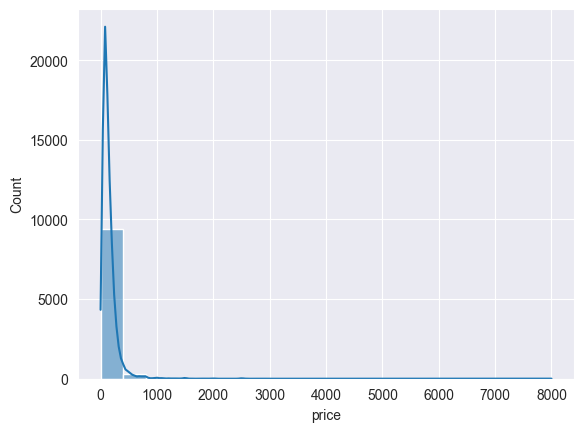

In [9]:
sns.histplot(airbnb['price'], kde = True, bins =20)
plt.show()

In [3]:
airbnb['price'] = airbnb['price'].astype(str).str.replace('$', '', regex=False).str.replace(',', '', regex=False)

airbnb['price'] = pd.to_numeric(airbnb['price'], errors='coerce')

df_clean = airbnb[airbnb['price'] > 0].copy()
df_clean = df_clean.dropna(subset=['price'])

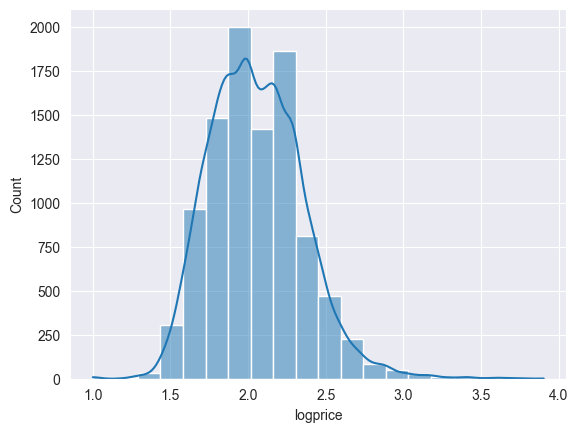

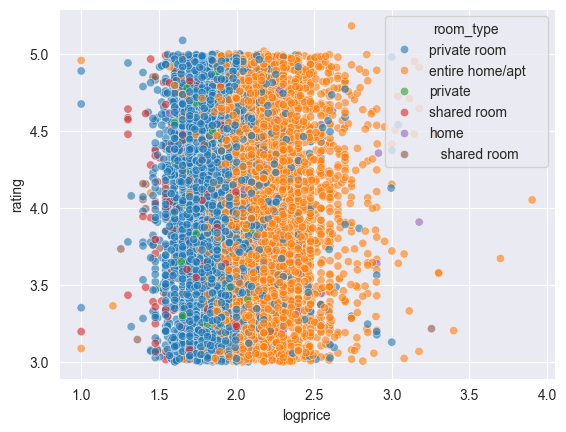

In [14]:

df_clean = airbnb[airbnb['price'] > 0].copy()

df_clean['logprice'] = np.log10(df_clean['price'])

sns.histplot(df_clean['logprice'], kde=True, bins=20)
plt.show()

sns.scatterplot(data=df_clean, x='logprice', y='rating', hue='room_type', alpha=0.6)

plt.show()

In [6]:
custom_bins = [0, 50, 100, 200, 1000, np.inf]

custom_labels = ['Very Cheap (0-50)', 'Cheap (50-100)', 'Average (100-200)', 'Expensive (200-1000)', 'Luxury (1000+)']

df_clean['custom_category'] = pd.cut(df_clean['price'], bins=custom_bins, labels=custom_labels)

summary_table = df_clean.groupby('custom_category', observed=False)['price'].agg(['min', 'max', 'count'])
summary_table.columns = ['Min Price', 'Max Price', 'Number of Listings']
summary_table.index.name = 'Segment'

display(summary_table)

,Min Price,Max Price,Number of Listings
Segment,,,
Very Cheap (0-50),10.0,50.0,1260
Cheap (50-100),51.0,100.0,3512
Average (100-200),101.0,200.0,3316
Expensive (200-1000),201.0,1000.0,1638
Luxury (1000+),1002.0,8000.0,53


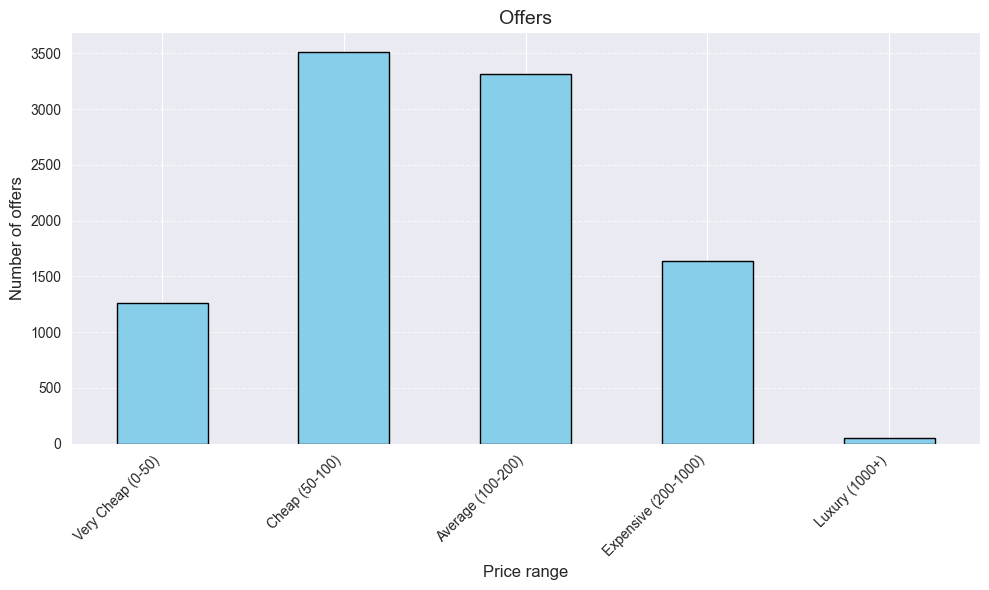

In [7]:
plt.figure(figsize=(10, 6))

summary_table['Number of Listings'].plot(
    kind='bar',
    color='skyblue',
    edgecolor='black'
)

plt.title('Offers', fontsize=14)
plt.xlabel('Price range', fontsize=12)
plt.ylabel('Number of offers', fontsize=12)

plt.xticks(rotation=45, ha='right')

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()

plt.show()

In [8]:
airbnb['room_type']= airbnb['room_type'].str.lower()
airbnb['room_type'].unique()

<StringArray>
[        'private room',      'entire home/apt',              'private',
          'shared room',                 'home', '   shared room      ']
Length: 6, dtype: str

In [10]:
mappings = {'private room': 'Private Room',
            'private': 'Private room',
            'entire home/apt': 'Entire place',
            'shared room': 'Shared room',
            'home': 'Entire place',
            '   shared room      ':'Shared room'}

airbnb['room_type'] = airbnb['room_type'].replace(mappings)
airbnb['room_type'].unique()

<StringArray>
['Private Room', 'Entire place', 'Private room', 'Shared room']
Length: 4, dtype: str

In [11]:
airbnb['price'] = (
    airbnb['price']
    .astype(str)
    .str.replace('$', '', regex=False)
    .str.strip()
)


airbnb['price']=airbnb['price'].astype('float')
airbnb['price'].mean()

np.float64(150.90512217564665)

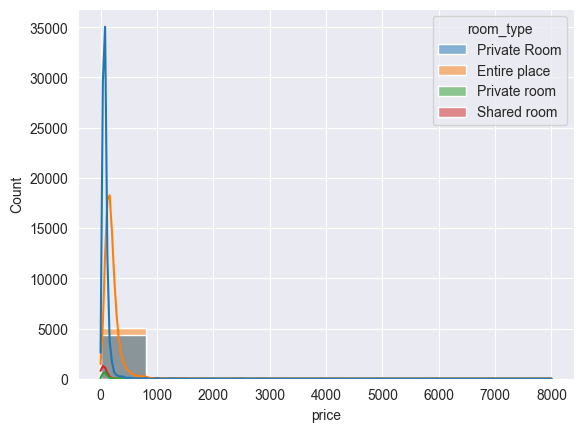

In [18]:
sns.histplot(data=airbnb, x='price', hue='room_type',kde=True, bins=10)
plt.show()

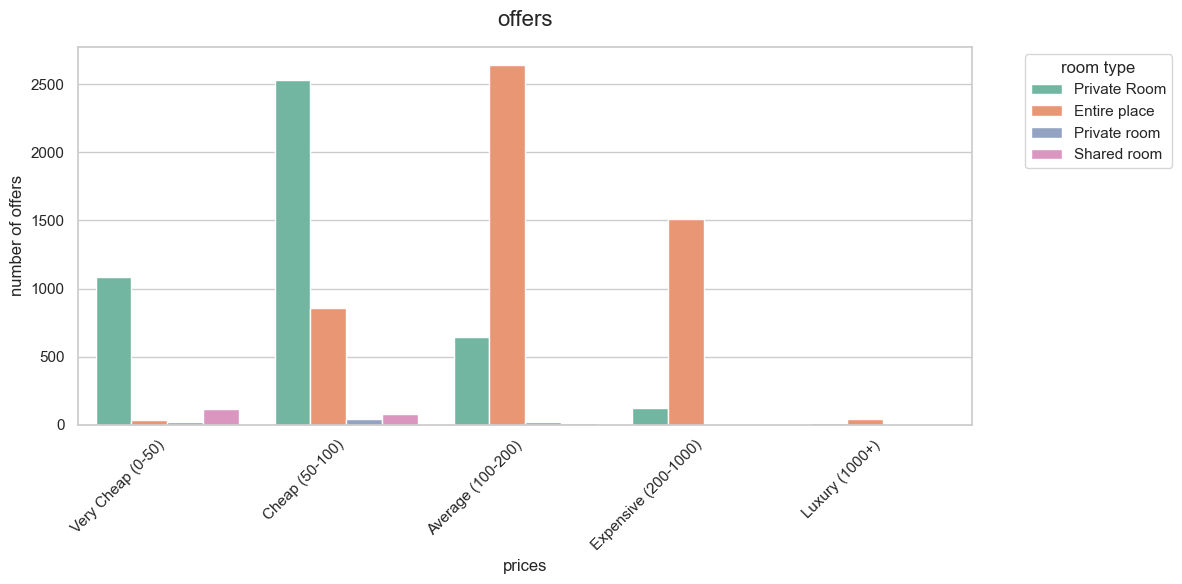

In [21]:
custom_bins = [0, 50, 100, 200, 1000, np.inf]
custom_labels = ['Very Cheap (0-50)', 'Cheap (50-100)', 'Average (100-200)', 'Expensive (200-1000)', 'Luxury (1000+)']
airbnb['custom_category'] = pd.cut(airbnb['price'], bins=custom_bins, labels=custom_labels)

plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

ax = sns.countplot(
    data=airbnb,
    x='custom_category',
    hue='room_type',
    palette='Set2'
)

plt.title('offers', fontsize=16, pad=15)
plt.xlabel('prices', fontsize=12)
plt.ylabel('number of offers', fontsize=12)

plt.xticks(rotation=45, ha='right')

plt.legend(title='room type', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()